In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


In [2]:
## Dataset Generation (Simple Linear Regression)


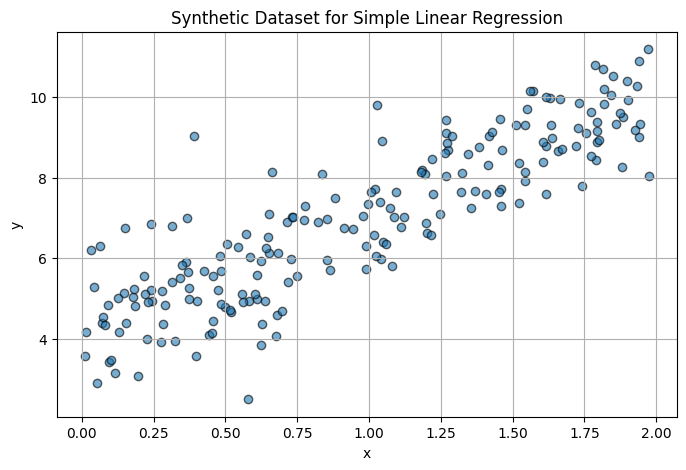

In [3]:
true_theta0, true_theta1 = 4.0, 3.0
m = 200

X_raw = 2 * np.random.rand(m, 1)                       # feature, shape (m, 1)
noise = np.random.randn(m, 1)
y = true_theta0 + true_theta1 * X_raw + noise           # target, shape (m, 1)

plt.scatter(X_raw, y, alpha=0.6, edgecolor="k")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Dataset for Simple Linear Regression")
plt.show()

In [4]:
## Implementation — `LinearRegressionScratch`

In [5]:
class LinearRegressionScratch:
    def __init__(self):
        self.theta = None
        self.cost_history = []

    @staticmethod
    def _add_bias(X):
        # Prepend a column of ones to X for the bias/intercept term.
        m = X.shape[0]
        return np.hstack([np.ones((m, 1)), X])

    @staticmethod
    def _compute_cost(X_b, y, theta):
        m = X_b.shape[0]
        errors = X_b.dot(theta) - y
        return (1 / (2 * m)) * np.sum(errors ** 2)

    def fit_gradient_descent(self, X, y, alpha=0.1, n_iter=1000, verbose=False):
        X_b = self._add_bias(X)
        m, n = X_b.shape
        self.theta = np.zeros((n, 1))
        self.cost_history = []

        for i in range(n_iter):
            errors = X_b.dot(self.theta) - y
            gradient = (1 / m) * X_b.T.dot(errors)
            self.theta -= alpha * gradient
            cost = self._compute_cost(X_b, y, self.theta)
            self.cost_history.append(cost)
            if verbose and i % (n_iter // 10 or 1) == 0:
                print(f"Iteration {i:5d} | Cost = {cost:.6f}")
        return self

    def fit_normal_equation(self, X, y):
        X_b = self._add_bias(X)
        self.theta = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        return self

    def predict(self, X):
        X_b = self._add_bias(X)
        return X_b.dot(self.theta)

    # ---- metrics ----
    @staticmethod
    def mse(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    @classmethod
    def rmse(cls, y_true, y_pred):
        return np.sqrt(cls.mse(y_true, y_pred))

    @staticmethod
    def mae(y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    @staticmethod
    def r2_score(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - ss_res / ss_tot


In [6]:
model_gd = LinearRegressionScratch()
model_gd.fit_gradient_descent(X_raw, y, alpha=0.1, n_iter=1000, verbose=True)

print("\nLearned parameters (Gradient Descent):")
print(f"theta_0 (intercept) = {model_gd.theta[0, 0]:.4f}  (true: {true_theta0})")
print(f"theta_1 (slope)     = {model_gd.theta[1, 0]:.4f}  (true: {true_theta1})")

Iteration     0 | Cost = 16.537465
Iteration   100 | Cost = 0.470928
Iteration   200 | Cost = 0.467062
Iteration   300 | Cost = 0.466919
Iteration   400 | Cost = 0.466913
Iteration   500 | Cost = 0.466913
Iteration   600 | Cost = 0.466913
Iteration   700 | Cost = 0.466913
Iteration   800 | Cost = 0.466913
Iteration   900 | Cost = 0.466913

Learned parameters (Gradient Descent):
theta_0 (intercept) = 4.1052  (true: 4.0)
theta_1 (slope)     = 2.9610  (true: 3.0)


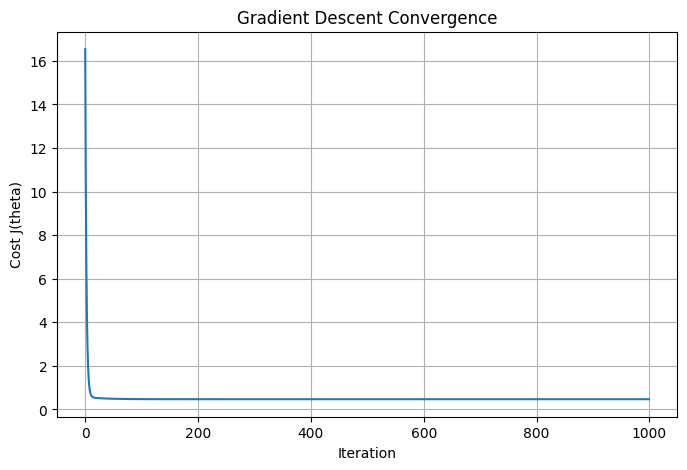

In [7]:
plt.plot(model_gd.cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.title("Gradient Descent Convergence")
plt.show()

In [8]:
model_ne = LinearRegressionScratch()
model_ne.fit_normal_equation(X_raw, y)

print("Learned parameters (Normal Equation):")
print(f"theta_0 (intercept) = {model_ne.theta[0, 0]:.4f}")
print(f"theta_1 (slope)     = {model_ne.theta[1, 0]:.4f}")


Learned parameters (Normal Equation):
theta_0 (intercept) = 4.1052
theta_1 (slope)     = 2.9610


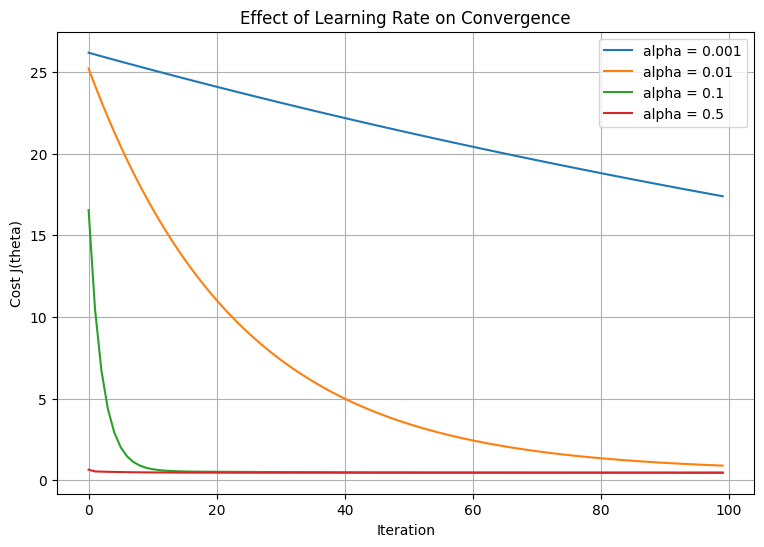

In [9]:
learning_rates = [0.001, 0.01, 0.1, 0.5]

plt.figure(figsize=(9, 6))
for alpha in learning_rates:
    m_temp = LinearRegressionScratch()
    m_temp.fit_gradient_descent(X_raw, y, alpha=alpha, n_iter=100)
    plt.plot(m_temp.cost_history, label=f"alpha = {alpha}")

plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.show()

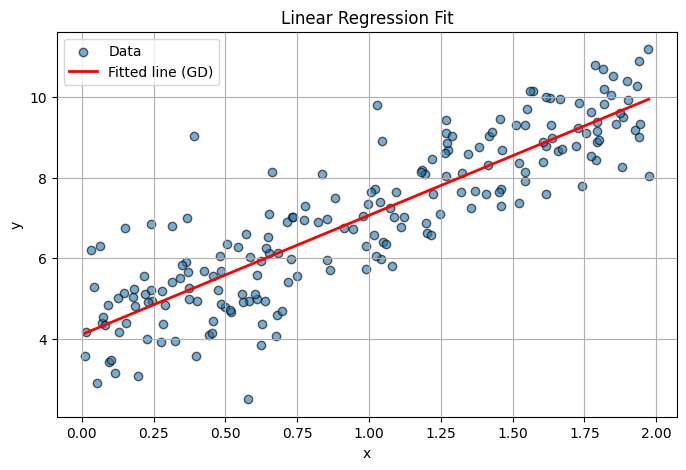

In [10]:
y_pred_line = model_gd.predict(X_raw)

plt.scatter(X_raw, y, alpha=0.6, edgecolor="k", label="Data")
order = np.argsort(X_raw[:, 0])
plt.plot(X_raw[order], y_pred_line[order], color="red", linewidth=2, label="Fitted line (GD)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

In [11]:
y_pred = model_gd.predict(X_raw)

print(f"MSE  : {LinearRegressionScratch.mse(y, y_pred):.4f}")
print(f"RMSE : {LinearRegressionScratch.rmse(y, y_pred):.4f}")
print(f"MAE  : {LinearRegressionScratch.mae(y, y_pred):.4f}")
print(f"R^2  : {LinearRegressionScratch.r2_score(y, y_pred):.4f}")

MSE  : 0.9338
RMSE : 0.9663
MAE  : 0.7628
R^2  : 0.7647


In [12]:
##  Multivariate Linear Regression on a Real Dataset

In [13]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes()
X_multi, y_multi = data.data, data.target.reshape(-1, 1)

print("Feature names:", data.feature_names)
print("X shape:", X_multi.shape, "| y shape:", y_multi.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X shape: (442, 10) | y shape: (442, 1)


In [14]:
import pandas as pd
df_diabetes = pd.DataFrame(X_multi, columns=data.feature_names)
df_diabetes["target"] = y_multi.ravel()

print("Shape:", df_diabetes.shape)
df_diabetes.describe()

Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [15]:
def standardize(X, mean=None, std=None):
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
        std[std == 0] = 1.0  # avoid division by zero for constant columns
    return (X - mean) / std, mean, std

X_train_scaled, train_mean, train_std = standardize(X_train)
X_test_scaled, _, _ = standardize(X_test, train_mean, train_std)

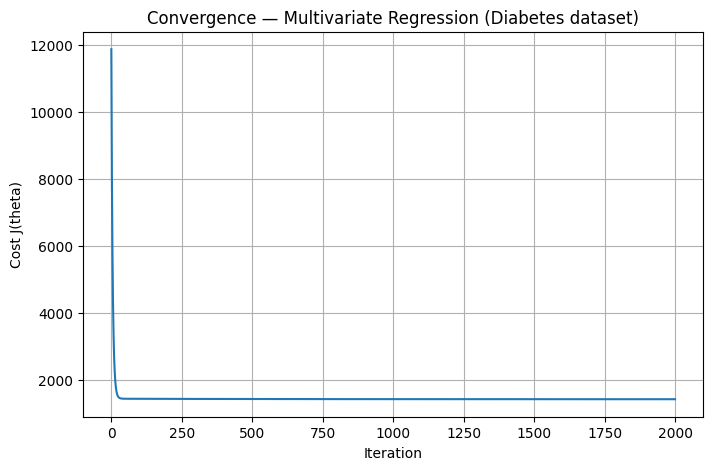

Test MSE  : 2895.3001
Test RMSE : 53.8080
Test MAE  : 42.8075
Test R^2  : 0.4535


In [16]:
model_multi = LinearRegressionScratch()
model_multi.fit_gradient_descent(X_train_scaled, y_train, alpha=0.1, n_iter=2000)

plt.plot(model_multi.cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.title("Convergence — Multivariate Regression (Diabetes dataset)")
plt.show()

y_test_pred = model_multi.predict(X_test_scaled)
print(f"Test MSE  : {LinearRegressionScratch.mse(y_test, y_test_pred):.4f}")
print(f"Test RMSE : {LinearRegressionScratch.rmse(y_test, y_test_pred):.4f}")
print(f"Test MAE  : {LinearRegressionScratch.mae(y_test, y_test_pred):.4f}")
print(f"Test R^2  : {LinearRegressionScratch.r2_score(y_test, y_test_pred):.4f}")

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score as sk_r2

# --- Simple regression comparison ---
sk_simple = LinearRegression().fit(X_raw, y)
print("Simple Linear Regression — scratch vs sklearn")
print(f"  scratch  : theta0={model_gd.theta[0,0]:.4f}, theta1={model_gd.theta[1,0]:.4f}")
print(f"  sklearn  : intercept={sk_simple.intercept_[0]:.4f}, coef={sk_simple.coef_[0,0]:.4f}")

# --- Multivariate comparison ---
sk_multi = LinearRegression().fit(X_train_scaled, y_train)
sk_pred = sk_multi.predict(X_test_scaled)

print("\nMultivariate Regression (Diabetes) — Test set metrics")
print(f"  scratch R^2  : {LinearRegressionScratch.r2_score(y_test, y_test_pred):.4f}")
print(f"  sklearn R^2  : {sk_r2(y_test, sk_pred):.4f}")
print(f"  scratch MSE  : {LinearRegressionScratch.mse(y_test, y_test_pred):.4f}")
print(f"  sklearn MSE  : {mean_squared_error(y_test, sk_pred):.4f}")

Simple Linear Regression — scratch vs sklearn
  scratch  : theta0=4.1052, theta1=2.9610
  sklearn  : intercept=4.1052, coef=2.9610

Multivariate Regression (Diabetes) — Test set metrics
  scratch R^2  : 0.4535
  sklearn R^2  : 0.4526
  scratch MSE  : 2895.3001
  sklearn MSE  : 2900.1936


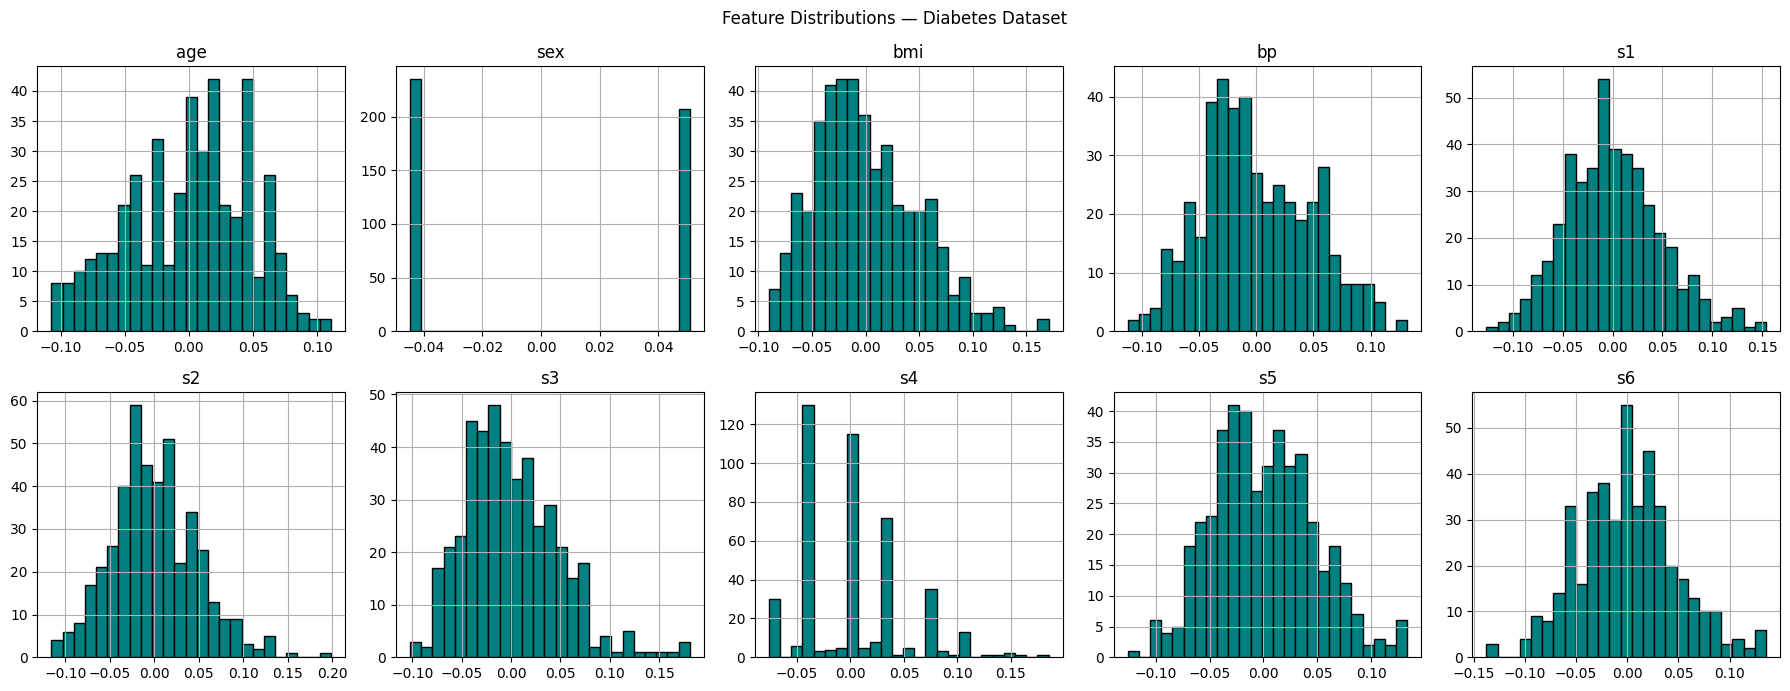

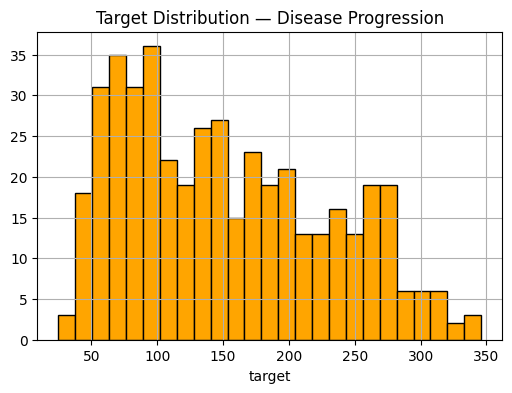

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), data.feature_names):
    ax.hist(df_diabetes[col], bins=25, color="teal", edgecolor="k")
    ax.set_title(col)
plt.suptitle("Feature Distributions — Diabetes Dataset")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_diabetes["target"], bins=25, color="orange", edgecolor="k")
plt.title("Target Distribution — Disease Progression")
plt.xlabel("target")
plt.show()

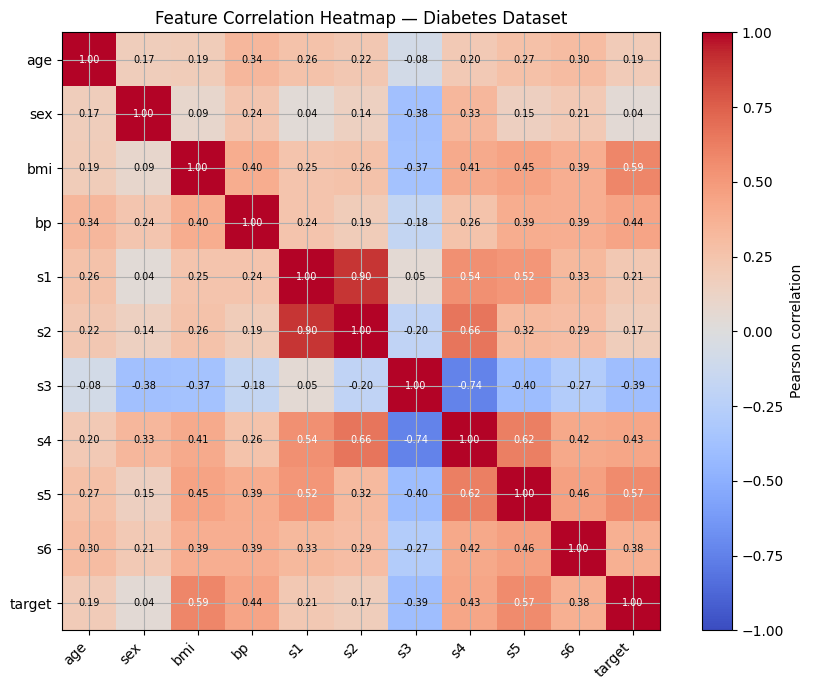

Features most correlated with target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


In [19]:
corr = df_diabetes.corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                  color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=7)
plt.title("Feature Correlation Heatmap — Diabetes Dataset")
plt.tight_layout()
plt.show()

print("Features most correlated with target:")
print(corr["target"].drop("target").sort_values(ascending=False))

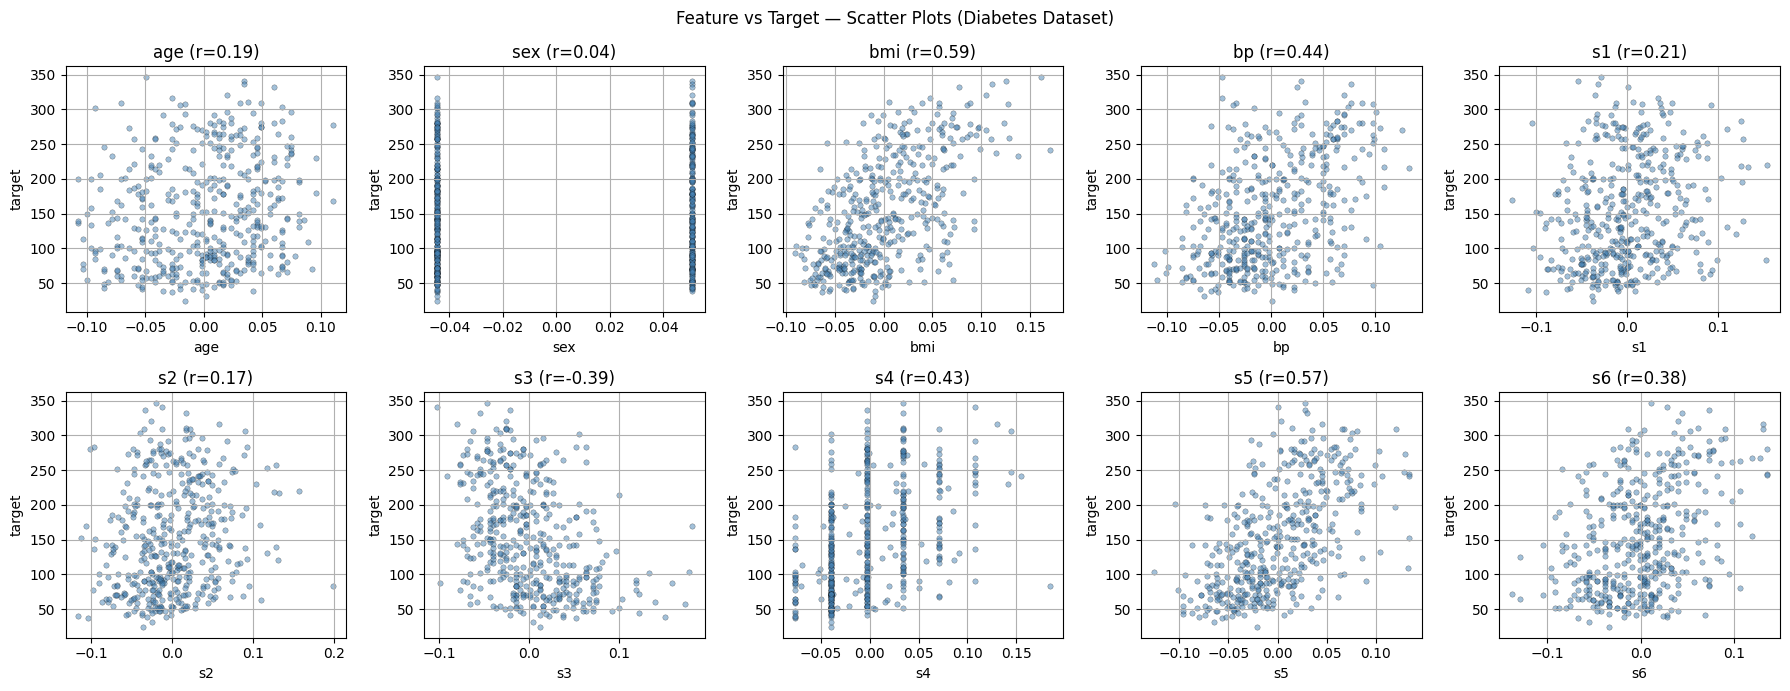

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), data.feature_names):
    ax.scatter(df_diabetes[col], df_diabetes["target"], alpha=0.5, s=15,
               edgecolor="k", linewidth=0.3, color="steelblue")
    ax.set_title(f"{col} (r={df_diabetes[col].corr(df_diabetes['target']):.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("target")
plt.suptitle("Feature vs Target — Scatter Plots (Diabetes Dataset)")
plt.tight_layout()
plt.show()

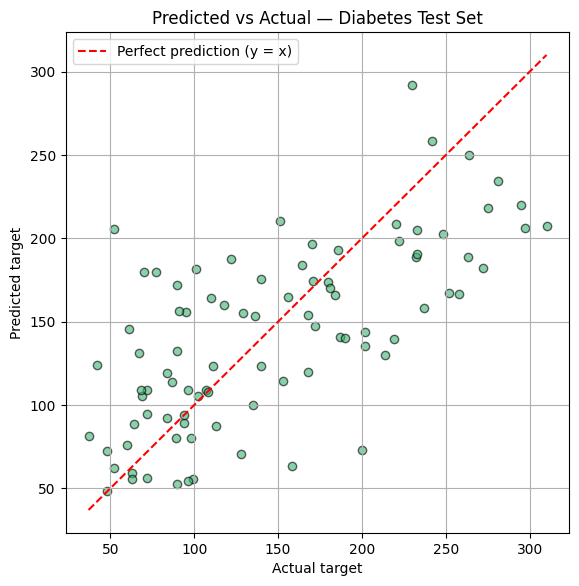

In [21]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolor="k", color="mediumseagreen")

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction (y = x)")

plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.title("Predicted vs Actual — Diabetes Test Set")
plt.legend()
plt.show()